In [ ]:
import numpy as np
import pandas as pd
from torch import nn
import torch
import tabulate
import numpy as np

data = [[1,2,3],[4,5,6]]

my_tensor = torch.tensor(data)

print(my_tensor)

tensor([[1, 2, 3],
        [4, 5, 6]])


In [ ]:
shape = (3,3)

jedynkowy = torch.ones(shape,dtype=float)
zerowy = torch.zeros(shape,dtype=float)
losowy = torch.randn(shape)

print(losowy)

tensor([[-1.4123, -0.9166, -0.8663],
        [-0.9349,  0.7114,  0.0042],
        [ 0.6536, -0.0087,  0.1595]])


In [ ]:
rand_like = torch.rand_like(my_tensor, dtype=float)
print(my_tensor)
print(rand_like)

tensor([[1, 2, 3],
        [4, 5, 6]])
tensor([[0.9821, 0.6282, 0.3504],
        [0.2165, 0.5194, 0.3601]], dtype=torch.float64)


In [ ]:
tensor  = torch.randn(2,2)

print(f"Shape {tensor.shape}")

print(f"Dtype {tensor.dtype}")

print(f"Device {tensor.device}")

print("skończylme na  40.25")

Shape torch.Size([2, 2])
Dtype torch.float32
Device cpu
skończylme na  8:40


In [ ]:
tensor = torch.randn(2,2)

In [ ]:
normal_tensor = torch.tensor([[1.0, 2.0],[3.0, 4.0]])
print(normal_tensor)

grad_tensor = torch.tensor([[1.0, 2.0],[3.0, 4.0]], requires_grad= True)
print(grad_tensor)

tensor([[1., 2.],
        [3., 4.]])
tensor([[1., 2.],
        [3., 4.]], requires_grad=True)


In [ ]:
#Building the graph

a = torch.tensor(2.0, requires_grad=True)
b = torch.tensor(3.0, requires_grad=True)
x = torch.tensor(4.0, requires_grad=True)
y = a + b

z = x * y
print(z.grad_fn)
print(y.grad_fn)
print(a.grad_fn)



None


In [ ]:
#Elementwise multiplication
#shape a must be equal to shape b

a = torch.tensor([[1,2,3], [3,4,5]])

b = torch.tensor([[2,2,2], [2,2,2]])
#mnoży indeksowo [[1*2, 2*2],[3*2 itd]]
result = a * b

print(result)

tensor([[ 2,  4,  6],
        [ 6,  8, 10]])


In [ ]:
#matrix multiplication
#do liniowej warstwy y = xw +b

m1 = torch.tensor([[1,2,3], [3,4,5]])
print(m1.shape)
m2 = torch.tensor([[1,2],[1,2],[1,2]])
print(m2.shape)
matrix_product = m1 @ m2

print(matrix_product, matrix_product.shape)

torch.Size([2, 3])
torch.Size([3, 2])
tensor([[ 6, 12],
        [12, 24]]) torch.Size([2, 2])


In [ ]:
scores = torch.tensor([[1,2,3], [3,4,5]],dtype=float)

average_score = scores.mean()

print(f"Overall Mean: {average_score}")

Overall Mean: 3.0


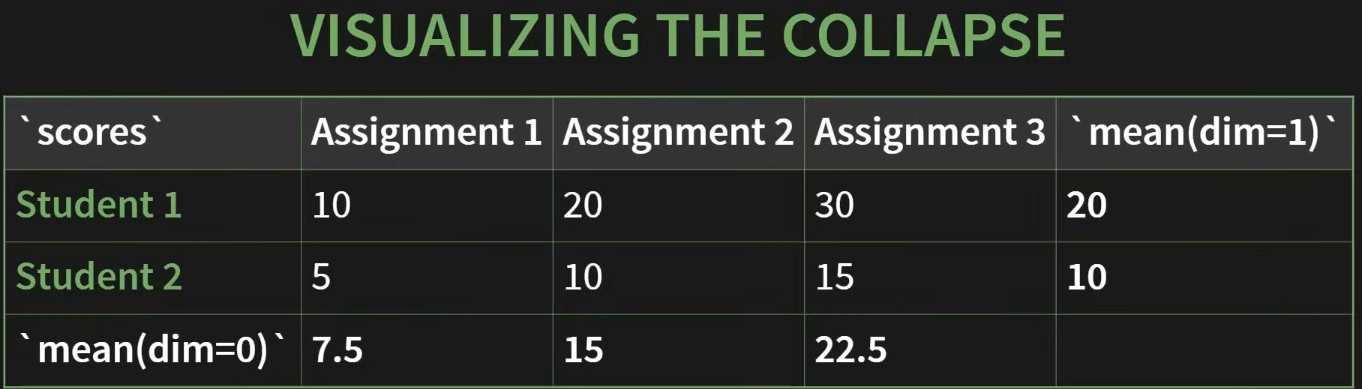

In [ ]:
scores = torch.tensor([[10.,20.,30.], [5.,10.,15.]])

score_per_assignment = scores.mean(dim=0)

score_per_student = scores.mean(dim=1)

print(f"score_per_assignment Mean(dim =0): {score_per_assignment},\nscore_per_student Mean(dim =1): {score_per_student}, ")

score_per_assignment Mean(dim =0): tensor([ 7.5000, 15.0000, 22.5000]),
score_per_student Mean(dim =1): tensor([20., 10.]), 


In [ ]:
#basic indexing
wygenerowany = torch.arange(12).reshape(3,4)
col_2 = wygenerowany[:,2]
print(wygenerowany)
print(col_2)

tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
tensor([ 2,  6, 10])


In [ ]:
#dynamic selection

scores = torch.tensor([
    [10,0,5,20,1],
    [1,30,2,5,0]
])

best_indices = torch.argmax(scores, dim=1)

print(best_indices)

tensor([3, 1])


In [ ]:
data = torch.tensor([[10,11,12,13],
                     [20,21,22,23],
                     [30,31,32,33]])

indices_to_select = torch.tensor([[2],[0],[3]])

selected_values = torch.gather(data, dim = 1, index= indices_to_select)

print(selected_values)

tensor([[12],
        [20],
        [33]])


Forward Pass

In [ ]:
#y = XW +b
#batch size
N = 10
#liczba inpuitów i ouitputów
D_in = 1
D_out = 1
#Tworzenie input data

X = torch.randn(N,D_in)

true_W = torch.tensor([[2.0]])
true_b = torch.tensor(1.0)

y_true = X @ true_W + true_b + torch.randn(N,D_out) * 0.1

print(y_true)

W = torch.randn(D_in, D_out, requires_grad=True)
b = torch.randn(1, requires_grad=True)

print(f"initial weight \n {W}")

print(f"initial bias \n {b}")

y_hat = X @ W + b

print(y_hat)    

tensor([[-1.7863],
        [-1.1321],
        [ 1.4937],
        [-1.1100],
        [ 0.2709],
        [ 0.2053],
        [ 0.1361],
        [-1.8630],
        [ 1.8521],
        [-3.1136]])
initial weight 
 tensor([[-0.1861]], requires_grad=True)
initial bias 
 tensor([1.1341], requires_grad=True)
tensor([[1.4061],
        [1.3264],
        [1.0778],
        [1.3388],
        [1.2006],
        [1.2017],
        [1.2162],
        [1.4083],
        [1.0707],
        [1.5093]], grad_fn=<AddBackward0>)


In [ ]:
#backward pass

error = y_hat - y_true
serror = error **2

loss = serror.mean()
#oblicza gradienty dla zmiennych które maja wplyw na loss
loss.backward() #mega ważne !!! daje informacje dla .grad atrybutu w która strone zmierza gradient

print(f"loss: {loss}")
print(f"Gradient for W: {W.grad}\n")
print(f"Gradient for b: {b.grad}\n") 

loss: 5.811310768127441
Gradient for W: tensor([[-5.1209]])

Gradient for b: tensor([3.5606])



In [ ]:
# #θ_t+1 = θ_t - η * ∇_θ L
# θ: Represents all our parameters, W and b.
# η (eta): The learning rate, a small number that controls how big of a step we take.
# ∇_θ L: The gradient of the loss with respect to our parameters, which we now have in W.grad and b.grad.

# Czyli:
# W_new = W_old - learning_rate * W.grad
# b_new = b_old - learning_rate * b.grad


lr, epochs = 0.01, 100

for epoch in range(epochs):
    #forward pass
    y_hat = X @ W + b
    loss = torch.mean((y_hat - y_true)**2)

    #backward pass
    loss.backward() 

    #updated parametry
    with torch.no_grad():
        W -= W.grad * lr 
        b -= b.grad * lr

    #wyzerowanie gradientów
    W.grad.zero_()
    b.grad.zero_()
    if epoch %10 == 0:
        print(f"Epoch {epoch}, loss {loss}")
        print(f"W = {W.item()}, b = {b.item()}")
        print(f"True parameters: W = {2}, b = {1}")

Epoch 0, loss 0.010224366560578346
W = 1.9511793851852417, b = 0.9642494320869446
True parameters: W = 2, b = 1
Epoch 10, loss 0.010072391480207443
W = 1.9538023471832275, b = 0.967108428478241
True parameters: W = 2, b = 1
Epoch 20, loss 0.009937809780240059
W = 1.9562709331512451, b = 0.9697991609573364
True parameters: W = 2, b = 1
Epoch 30, loss 0.009818599559366703
W = 1.9585939645767212, b = 0.9723314642906189
True parameters: W = 2, b = 1
Epoch 40, loss 0.0097130062058568
W = 1.9607802629470825, b = 0.9747147560119629
True parameters: W = 2, b = 1
Epoch 50, loss 0.009619482792913914
W = 1.962838053703308, b = 0.9769576787948608
True parameters: W = 2, b = 1
Epoch 60, loss 0.00953664630651474
W = 1.9647746086120605, b = 0.9790686368942261
True parameters: W = 2, b = 1
Epoch 70, loss 0.00946327205747366
W = 1.966597080230713, b = 0.9810552597045898
True parameters: W = 2, b = 1
Epoch 80, loss 0.009398287162184715
W = 1.968312382698059, b = 0.9829249382019043
True parameters: W = 2

 # Torch.nn 

In [ ]:
D_in = 1
D_out = 1

linear_layer = torch.nn.Linear(in_features= D_in, out_features=D_out)

print(f" linear_layer.weight W: {linear_layer.weight}\n")
print(f" linear_layer.bias b: {linear_layer.bias}\n")

y_hat_nn = linear_layer(X)

print(f"output warstwy linearnej \n {y_hat_nn[:3]}")

 linear_layer.weight W: Parameter containing:
tensor([[0.5249]], requires_grad=True)

 linear_layer.bias B: Parameter containing:
tensor([0.3510], requires_grad=True)

output warstwy linearnej 
 tensor([[-0.4164],
        [-0.1915],
        [ 0.5098]], grad_fn=<SliceBackward0>)


In [ ]:
#RELU

relu = torch.nn.ReLU()
gelu = torch.nn.GELU()
sigm = torch.nn.Sigmoid()
sample_data = torch.tensor([-2.0,-0.5,0.0, 0.5, 2.0])
activated_data = relu(sample_data)

print(f"Pierwotne dane \n {sample_data}")
print(f"Dane po aktywacji relu\n{activated_data} ")
print(f"Dane po aktywacji gelu \n{gelu(sample_data)}")
print(f"Dane po aktywacji sigmoid \n{sigm(sample_data)}")


Pierwotne dane 
 tensor([-2.0000, -0.5000,  0.0000,  0.5000,  2.0000])
Dane po aktywacji relu
tensor([0.0000, 0.0000, 0.0000, 0.5000, 2.0000]) 
Dane po aktywacji gelu 
tensor([-0.0455, -0.1543,  0.0000,  0.3457,  1.9545])
Dane po aktywacji sigmoid 
tensor([0.1192, 0.3775, 0.5000, 0.6225, 0.8808])


In [ ]:
softmax = torch.nn.Softmax(dim=1)

logits = torch.tensor([[1.0,3.0,0.5,1.5],[-1.0,2.0,1.0,0.0]])
probabilities  = softmax(logits)

print(f"Prawdopodobieństwa \n{probabilities}")
print(f"Prawdopodobieństwa suma dla indeksie 0 \n{probabilities[0].sum()}")

Prawdopodobieństwa 
tensor([[0.0939, 0.6942, 0.0570, 0.1549],
        [0.0321, 0.6439, 0.2369, 0.0871]])
Prawdopodobieństwa suma dla indeksie 0 
1.0


In [ ]:
## nn.embeddings

vocab_size = 10
embedding_dim = 3 #każde słowo reprezentujemy jako vector 3- wymiarowy

embedding_layer = torch.nn.Embedding(vocab_size, embedding_dim)

input_ids = torch.tensor([[1,5,0,8]]) #id słów
word_vectors = embedding_layer(input_ids)

print(shape(word_vectors))